<hr style="border:2px solid #0281c9"> </hr>

<img align="left" alt="ESO Logo" src="http://archive.eso.org/i/esologo.png">  

<div align="center">
  <h1 style="color: #0281c9; font-weight: bold;">ESO Science Archive</h1> 
  <h2 style="color: #0281c9; font-weight: bold;">Jupyter Notebooks</h2>
</div>

<hr style="border:2px solid #0281c9"> </hr>

GRAVITY....

## **Importing the necessary modules**

In [1]:
# Use postponed evaluation of type hints (PEP 563).
# This means annotations are stored as strings and not evaluated at runtime,
# making forward references and imports cleaner. Enabled by default in Python ≥3.11.
from __future__ import annotations

# --- Standard library ---
import os
import shutil
import tempfile
from pathlib import Path

# --- Third-party scientific libraries ---
import numpy as np
import requests
from matplotlib import pyplot as plt

# --- Astropy (astronomy-specific) ---
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.utils.data import download_file
from astropy.wcs import WCS

# --- Optional: progress bar support (works in Jupyter & CLI) ---
try:
    from tqdm import tqdm
    _HAS_TQDM = True
except Exception:
    _HAS_TQDM = False

# Print key package and python versions
import sys
print("Environment Information:\n")
print(f"{'Python':<12} {sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}")
for pkg in ["numpy", "matplotlib", "astropy", "requests", "tqdm"]:
    try:
        mod = __import__(pkg)
        print(f"{pkg:<12} {mod.__version__}")
    except ImportError:
        print(f"{pkg:<12} not installed")

Environment Information:

Python       3.13.5
numpy        2.3.2
matplotlib   3.10.5
astropy      7.1.0
requests     2.32.4
tqdm         4.67.1


## **Define some useful functions** 

## **Retrieve the GRAVITY dataset**

In [2]:
proposal_id = "like '113.268%'" 
column_filters = {'proposal_id': proposal_id}

In [45]:
# coords = SkyCoord("17 45 40.00 -29 00 26.9", frame="fk5",  unit=(u.hourangle, u.deg)) # Convert target name to coordinates
coords = SkyCoord.from_name("FS CMA")
ra = coords.ra.deg # Right Ascension in degrees
dec = coords.dec.deg # Declination in degrees
radius = (20*u.arcsec).to("deg").value # Radius in degrees

In [46]:
from astroquery.eso import Eso # import the ESO module from astroquery
eso = Eso() # create an instance of the ESO class 
eso.ROW_LIMIT = -1 

table = eso.query_surveys("GRAVITY", 
                          cone_ra=ra, 
                          cone_dec=dec, 
                          cone_radius=radius, 
                        #   column_filters=column_filters
                          ) # query the ESO archive for GRAVITY data around the specified coordinates

table

target_name,s_ra,s_dec,dp_id,proposal_id,abmaglim,access_estsize,access_format,access_url,bib_reference,calib_level,dataproduct_subtype,dataproduct_type,em_max,em_min,em_res_power,em_xel,facility_name,filter,gal_lat,gal_lon,instrument_name,is_solar,last_mod_date,multi_ob,n_obs,o_calib_status,o_ucd,obs_collection,obs_creator_did,obs_creator_name,obs_id,obs_publisher_did,obs_release_date,obs_title,obstech,p3orig,pol_states,pol_xel,preview_html,publication_date,release_description,s_fov,s_pixel_scale,s_region,s_resolution,s_xel1,s_xel2,snr,strehl,t_exptime,t_max,t_min,t_resolution,t_xel
,deg,deg,,,mag,kbyte,,,,,,,m,m,,,,,deg,deg,,,,,,,,,,,,,,,,,,,,,,deg,arcsec,,arcsec,,,,,s,d,d,s,
object,float64,float64,object,object,float64,int64,object,object,object,int32,object,object,float64,float64,float64,int64,object,object,float64,float64,object,int16,object,object,int32,object,object,object,object,object,object,object,object,object,object,object,object,int64,object,object,object,float64,float64,object,float64,int64,int64,float64,float64,float64,float64,float64,float64,int64
HD 45677,97.070318,-13.05308,ADP.2025-12-18T10:31:06.332,106.212G.001,--,19177,application/x-votable+xml;content=datalink,http://archive.eso.org/datalink/links?ID=ivo://eso.org/ID?ADP.2025-12-18T10:31:06.332,2001PASP..112.1133P,2,uncalibrated,visibility,2.400264e-06,1.969735e-06,4133.71484375,1,ESO-VLTI-A1234,,-10.978314,222.08734,GRAVITY,0,2025-12-18T10:37:36.857Z,S,2,,,GRAVITY,ivo://eso.org/origfile?GR_SSVS_2992215_2021-02-20T02:56:32.232_A1234_SINGLE_HI_COMB.fits,"GARCIA LOPEZ, REBECA",2992215,ivo://eso.org/ID?ADP.2025-12-18T10:31:06.332,2022-02-20T03:26:14Z,,"INTERFEROMETRY,DIRECT",IDP,,--,https://archive.eso.org/dataset/ADP.2025-12-18T10:31:06.332,2025-12-18T10:33:44Z,http://www.eso.org/rm/api/v1/public/releaseDescriptions/242,--,--,POSITION J2000 97.070318 -13.05308,--,--,--,--,--,360.0,59265.13622992,59265.12259528,1178.032896,--
HD 45677,97.072596,-13.05308,ADP.2025-12-18T07:44:57.945,0104.C-0567(A),--,47517,application/x-votable+xml;content=datalink,http://archive.eso.org/datalink/links?ID=ivo://eso.org/ID?ADP.2025-12-18T07:44:57.945,2001PASP..112.1133P,2,uncalibrated,visibility,2.400264e-06,1.969735e-06,4133.71484375,1,ESO-VLTI-A1234,,-10.976312,222.088317,GRAVITY,0,2025-12-18T07:52:35.843Z,S,5,,,GRAVITY,ivo://eso.org/origfile?GR_SSVS_2728375_2020-01-27T01:50:27.727_A1234_SINGLE_HI_COMB.fits,"GARCIA LOPEZ, REBECA",2728375,ivo://eso.org/ID?ADP.2025-12-18T07:44:57.945,2021-01-27T02:40:34Z,,"INTERFEROMETRY,DIRECT",IDP,,--,https://archive.eso.org/dataset/ADP.2025-12-18T07:44:57.945,2025-12-18T07:48:40Z,http://www.eso.org/rm/api/v1/public/releaseDescriptions/242,--,--,POSITION J2000 97.072596 -13.05308,--,--,--,--,--,300.0,58875.1042571,58875.0767098,2380.08672,--
HD 45677,97.070318,-13.05308,ADP.2025-12-18T07:48:02.275,0104.C-0567(C),--,56969,application/x-votable+xml;content=datalink,http://archive.eso.org/datalink/links?ID=ivo://eso.org/ID?ADP.2025-12-18T07:48:02.275,2001PASP..112.1133P,2,uncalibrated,visibility,2.400264e-06,1.969735e-06,4133.71484375,1,ESO-VLTI-A1234,,-10.978314,222.08734,GRAVITY,0,2025-12-18T07:57:35.617Z,S,6,,,GRAVITY,ivo://eso.org/origfile?GR_SSVS_2750327_2020-02-04T01:32:35.866_A1234_SINGLE_HI_COMB.fits,"GARCIA LOPEZ, REBECA",2750327,ivo://eso.org/ID?ADP.2025-12-18T07:48:02.275,2021-02-04T02:30:40Z,,"INTERFEROMETRY,DIRECT",IDP,,--,https://archive.eso.org/dataset/ADP.2025-12-18T07:48:02.275,2025-12-18T07:53:49Z,http://www.eso.org/rm/api/v1/public/releaseDescriptions/242,--,--,POSITION J2000 97.070318 -13.05308,--,--,--,--,--,300.0,58883.09924744,58883.064304,3019.113216,--
HD_45677,97.07032,-13.05309,ADP.2025-12-17T14:16:43.439,0100.C-0354(A),--,17115,application/x-votable+xml;content=datalink,http://archive.eso.org/datalink/links?ID=ivo://eso.org/ID?ADP.2025-12-17T14:16:43.439,2001PASP..112.1133P,2,uncalibrated,visibility,2.4522e-06,1.987799e-06,504.3260803222656,1,ESO-VLTI-A1234,,-10.978316,222.08735,GRAVITY,0,2025-12-17T14:22:37.437Z,S,

In [47]:
print_unique = ["proposal_id", "target_name", "instrument_name"]

for col in print_unique:
    print(f"\nUnique values for column '{col}':")
    print(np.unique(table[col]))


Unique values for column 'proposal_id':
 proposal_id  
--------------
0100.C-0354(A)
0104.C-0567(A)
0104.C-0567(C)
  106.212G.001
  112.25T1.006

Unique values for column 'target_name':
target_name
-----------
  HD  45677
   HD 45677
   HD_45677

Unique values for column 'instrument_name':
instrument_name
---------------
        GRAVITY


In [48]:
table_ancillary = eso.query_ancillary(table["dp_id"][:3], column_filters={"eso_category": "ANCILLARY.PREVIEW"})
table_ancillary

access_estsize,access_url,archive_id,eso_category,extension,internal_file_id,original_filename,product_id
kbyte,,,,,,,
int64,object,object,object,object,int64,object,object
244,https://dataportal.eso.org/dataPortal/file/ADP.2025-12-18T07:44:57.946,ADP.2025-12-18T07:44:57.946,ANCILLARY.PREVIEW,PNG,39895126,r.GRAVI.2020-01-27T01:50:27.727_tpl_0000.png,ADP.2025-12-18T07:44:57.945
906,https://dataportal.eso.org/dataPortal/file/ADP.2025-12-18T07:44:57.947,ADP.2025-12-18T07:44:57.947,ANCILLARY.PREVIEW,PNG,39895127,r.GRAVI.2020-01-27T01:50:27.727_tpl_B00.png,ADP.2025-12-18T07:44:57.945
228,https://dataportal.eso.org/dataPortal/file/ADP.2025-12-18T07:48:02.276,ADP.2025-12-18T07:48:02.276,ANCILLARY.PREVIEW,PNG,39895279,r.GRAVI.2020-02-04T01:32:35.866_tpl_0000.png,ADP.2025-12-18T07:48:02.275
894,https://dataportal.eso.org/dataPortal/file/ADP.2025-12-18T07:48:02.277,ADP.2025-12-18T07:48:02.277,ANCILLARY.PREVIEW,PNG,39895280,r.GRAVI.2020-02-04T01:32:35.866_tpl_B00.png,ADP.2025-12-18T07:48:02.275
237,https://dataportal.eso.org/dataPortal/file/ADP.2025-12-18T10:31:06.333,ADP.2025-12-18T10:31:06.333,ANCILLARY.PREVIEW,PNG,39897052,r.GRAVI.2021-02-20T02:56:32.232_tpl_0000.png,ADP.2025-12-18T10:31:06.332
951,https://dataportal.eso.org/dataPortal/file/ADP.2025-12-18T10:31:06.334,ADP.2025-12-18T10:31:06.334,ANCILLARY.PREVIEW,PNG,39897053,r.GRAVI.2021-02-20T02:56:32.232_tpl_B00.png,ADP.2025-12-18T10:31:06.332


In [49]:
table_ancillary["filenames"] = eso.retrieve_data(table_ancillary["archive_id"], destination="./data/")

INFO: Downloading datasets ... [astroquery.eso.core]
INFO: Downloading 6 files ... [astroquery.eso.core]
INFO: Downloading file 1/6 https://dataportal.eso.org/dataPortal/file/ADP.2025-12-18T07:44:57.946 to /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/astroquery_examples_eso/examples/case_studies/data [astroquery.eso.core]
INFO: Successfully downloaded dataset ADP.2025-12-18T07:44:57.946 to /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/astroquery_examples_eso/examples/case_studies/data/ADP.2025-12-18T07:44:57.946.png [astroquery.eso.core]
INFO: Downloading file 2/6 https://dataportal.eso.org/dataPortal/file/ADP.2025-12-18T07:44:57.947 to /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/astroquery_examples_eso/examples/case_studies/data [astroquery.eso.core]
INFO: Successfully downloaded dataset ADP.2025-12-18T07:44:57.947 to /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/astroquery_examples_eso/examples/case_studies/data/ADP.2025-12-18T07:44:57.947.png [astroquery.eso.c

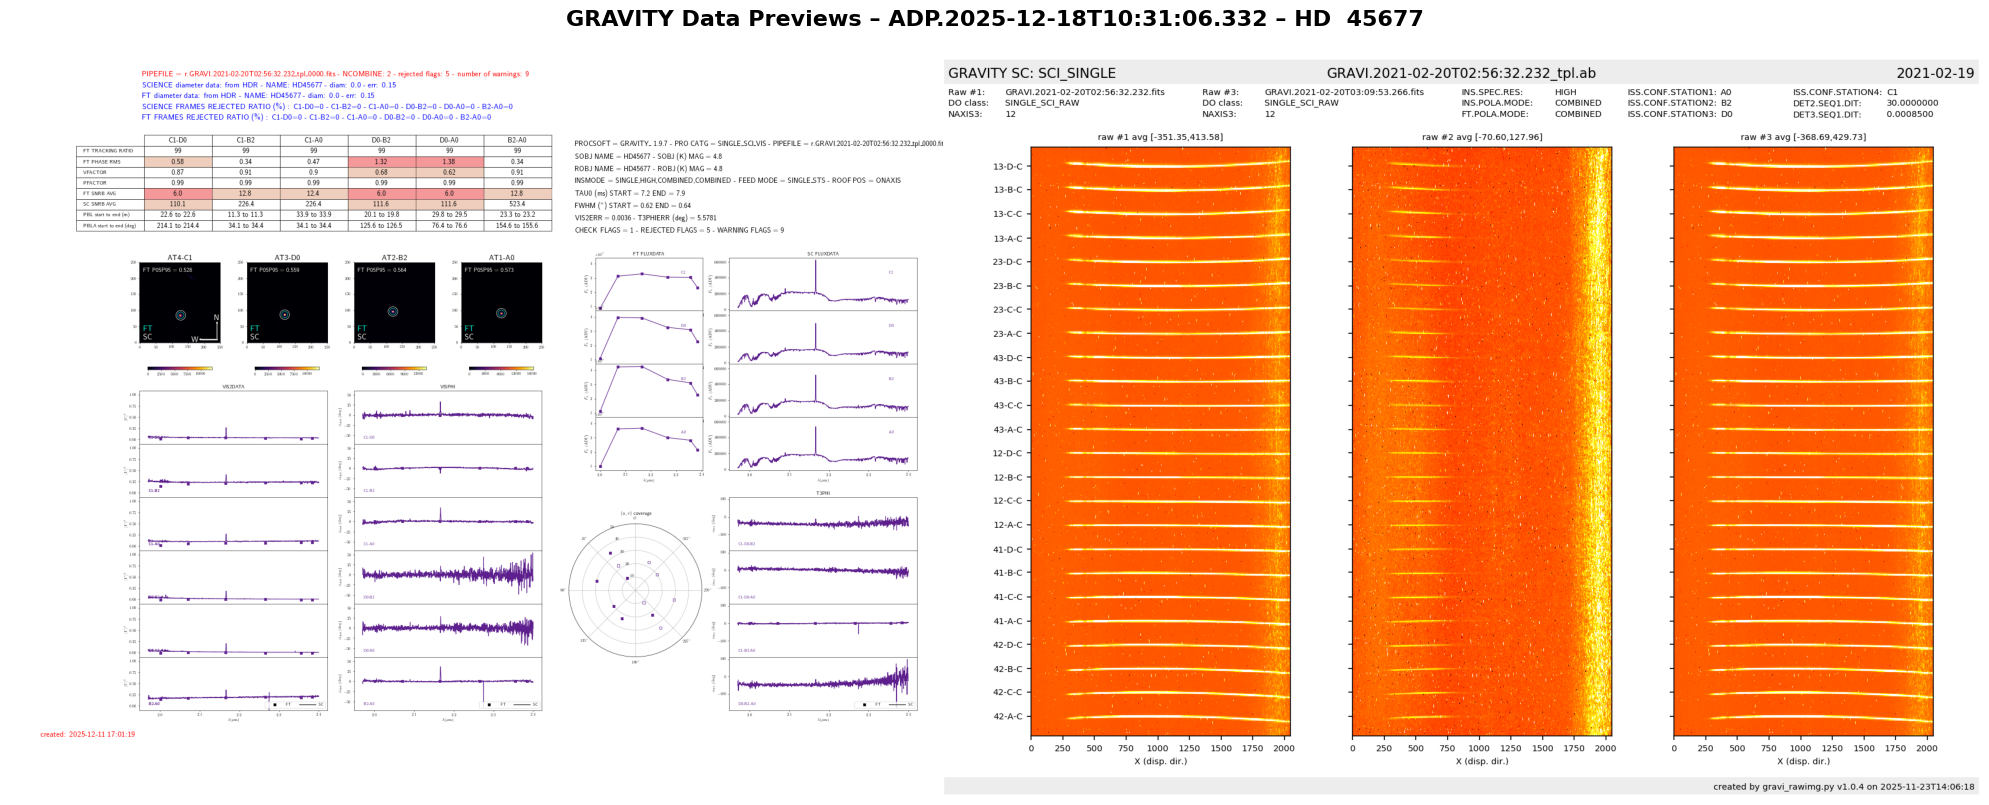

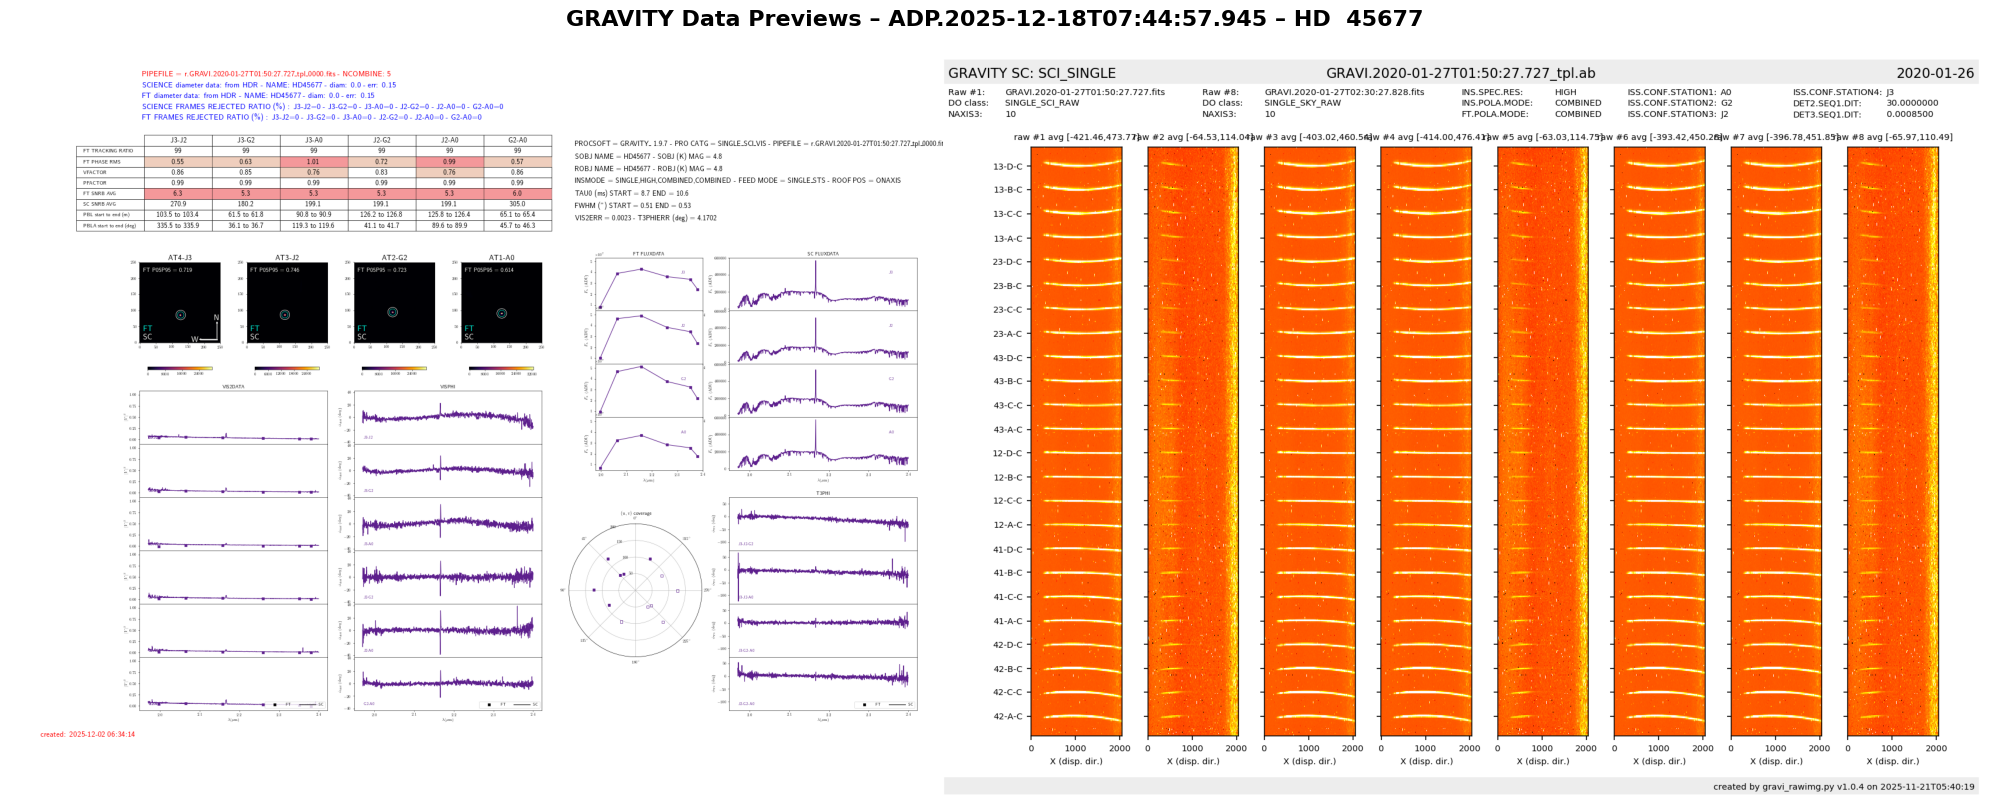

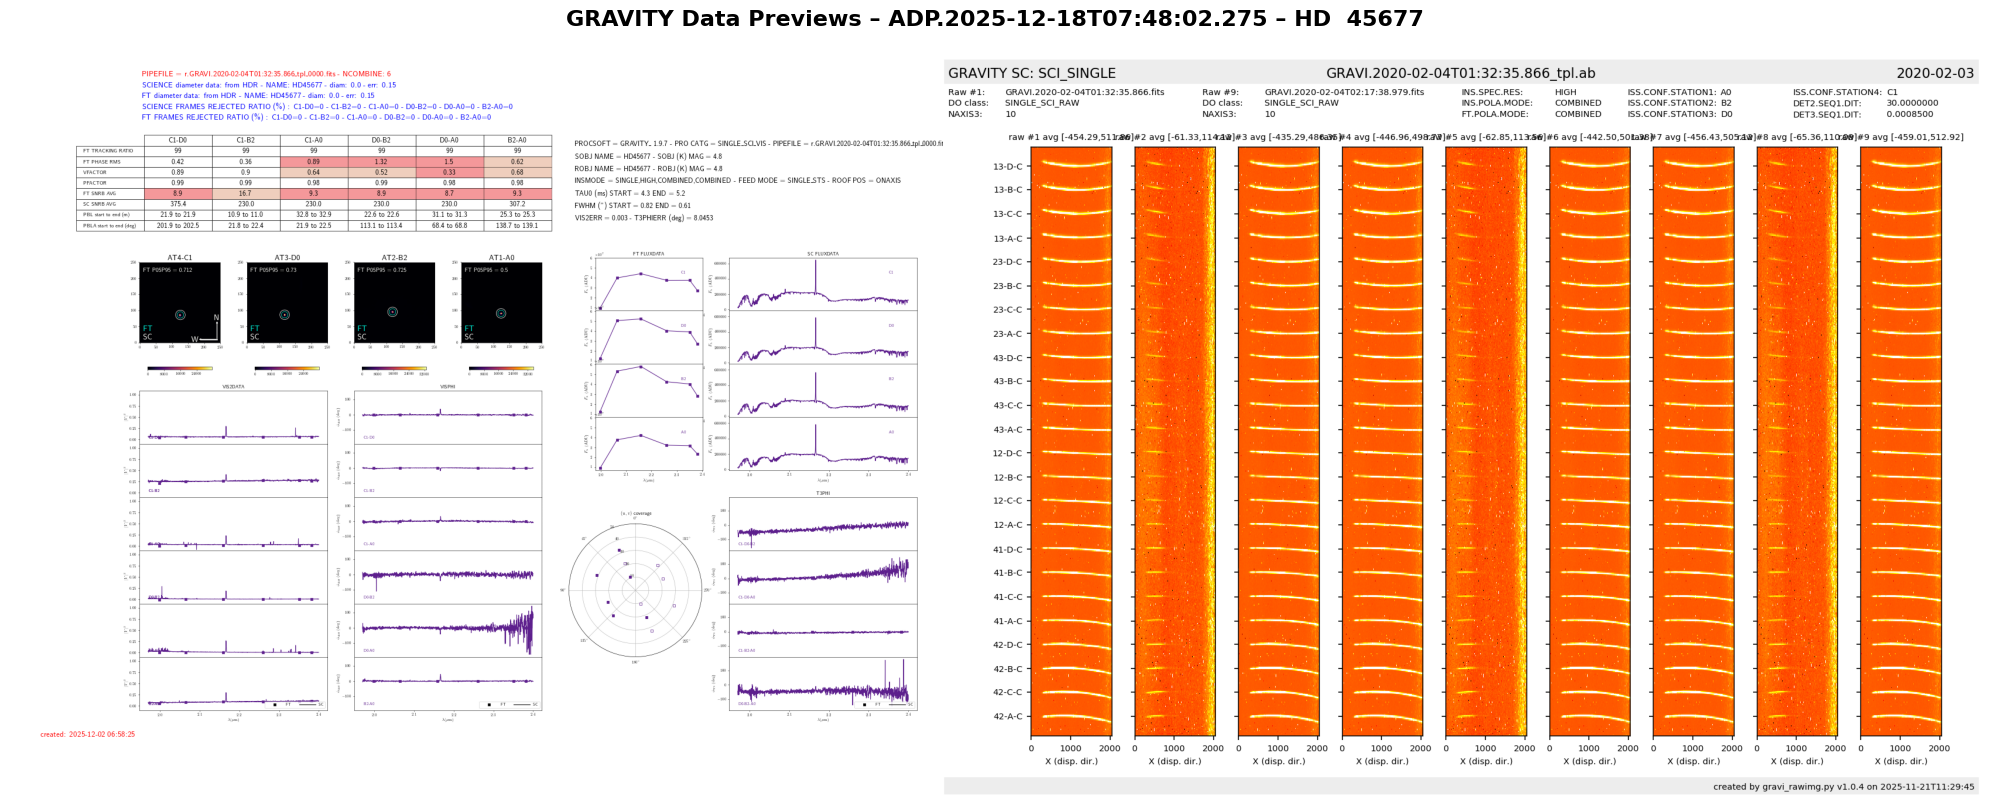

In [50]:
from PIL import Image
import matplotlib.pyplot as plt

_table = table[:3]
for row in _table:
    product_id = row["dp_id"]
    target_name = row["target_name"]

    # select the two ancillary rows belonging to this product
    mask = table_ancillary["product_id"] == product_id
    ancillary_rows = table_ancillary[mask]

    if len(ancillary_rows) != 2:
        print(f"Skipping {product_id}: expected 2 ancillary files, got {len(ancillary_rows)}")
        continue

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

    fig.suptitle(
        f"GRAVITY Data Previews – {product_id} – {target_name}",
        fontsize=16,
        fontweight="bold",
        y=0.9,
    )

    img1 = Image.open(ancillary_rows["filenames"][0])
    img2 = Image.open(ancillary_rows["filenames"][1])

    ax1.imshow(img1)
    ax2.imshow(img2)

    ax1.axis("off")
    ax2.axis("off")

    fig.tight_layout(w_pad=0)
    fig.subplots_adjust(wspace=-0.1)